<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Mini Transformer Language Model</b>
</h1>
<div style="font-family:'Times New Roman';">
Putting the block from notebook 02 into a small language model and training it on the exact same paragraph i used for the char RNN back in Day 49 to 50. Same data means the two can actually be compared instead of me guessing which is better.
</div>

## one difference from the RNN version

the RNN predicted **one** next character from a window of 25. this predicts the next character at **every** position at once, so a block of 32 characters gives 32 training signals instead of 1.

thats a big part of why transformers train faster, more supervision from the same data.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time

torch.manual_seed(0)

text = """machine learning is the study of algorithms that improve with data.
a model learns patterns from examples instead of being programmed with rules.
training means adjusting the weights so that the loss becomes smaller.
the loss tells the model how wrong it is on the training data.
gradient descent moves the weights in the direction that reduces the loss.
a neural network is layers of weights with a non linear function between them.
deep learning is neural networks with many layers stacked together.
overfitting happens when the model memorises the training data.
regularisation and more data are the usual fixes for overfitting.
a recurrent network keeps a hidden state so it can handle sequences."""

chars = sorted(set(text))
V = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
data = torch.tensor([stoi[ch] for ch in text])

print("characters :", len(text), " vocab :", V)

characters : 700  vocab : 28


In [2]:
BLOCK = 32

X = torch.stack([data[i:i+BLOCK]     for i in range(len(data) - BLOCK)])
Y = torch.stack([data[i+1:i+BLOCK+1] for i in range(len(data) - BLOCK)])

print("X :", tuple(X.shape), " Y :", tuple(Y.shape))
print("input  :", repr("".join(chars[i] for i in X[0])))
print("target :", repr("".join(chars[i] for i in Y[0])), " (same thing shifted by one)")

X : (668, 32)  Y : (668, 32)
input  : 'machine learning is the study of'
target : 'achine learning is the study of '  (same thing shifted by one)


## the model

2 layers, 4 heads, width 64. positional encoding is a learnt embedding here instead of the sine version, both are used in practice and learnt is simpler to write.

In [3]:
D, H, L = 64, 4, 2

tok_emb = nn.Embedding(V, D)
pos_emb = nn.Embedding(BLOCK, D)
attn  = [nn.MultiheadAttention(D, H, batch_first=True) for _ in range(L)]
ff    = [nn.Sequential(nn.Linear(D, 4*D), nn.GELU(), nn.Linear(4*D, D)) for _ in range(L)]
norm1 = [nn.LayerNorm(D) for _ in range(L)]
norm2 = [nn.LayerNorm(D) for _ in range(L)]
head  = nn.Linear(D, V)

modules = [tok_emb, pos_emb, head] + attn + ff + norm1 + norm2
params = [p for m in modules for p in m.parameters()]
print("parameters :", sum(p.numel() for p in params))

parameters : 105628


In [4]:
causal = torch.triu(torch.ones(BLOCK, BLOCK) * float('-inf'), diagonal=1)

def forward(x, return_attention=False):
    T = x.shape[1]
    h = tok_emb(x) + pos_emb(torch.arange(T))
    maps = []

    for i in range(L):
        z = norm1[i](h)
        a, w = attn[i](z, z, z, attn_mask=causal[:T, :T], need_weights=return_attention)
        h = h + a
        h = h + ff[i](norm2[i](h))
        if return_attention:
            maps.append(w)

    return head(h), maps

## training

In [6]:
opt = torch.optim.Adam(params, lr=0.003)
hist = []
start = time.time()

for epoch in range(300):
    logits, _ = forward(X)
    loss = F.cross_entropy(logits.reshape(-1, V), Y.reshape(-1))

    opt.zero_grad(); loss.backward(); opt.step()
    hist.append(loss.item())

    if epoch % 75 == 0:
        print("epoch", str(epoch).rjust(3), " loss", round(loss.item(), 4))

took = time.time() - start
print("trained in", round(took, 1), "seconds")

epoch   0  loss 3.498


epoch  75  loss 0.3979


epoch 150  loss 0.1227


epoch 225  loss 0.1165


trained in 54.9 seconds


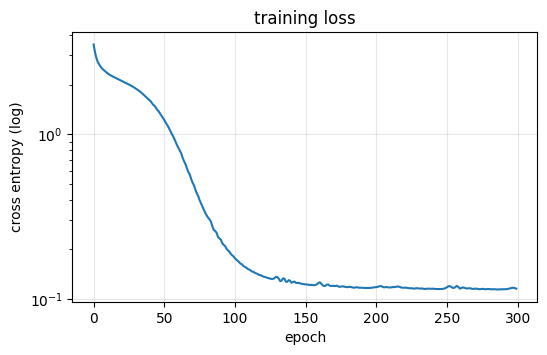

In [8]:
plt.figure(figsize=(6,3.5))
plt.semilogy(hist)
plt.xlabel('epoch'); plt.ylabel('cross entropy (log)'); plt.grid(alpha=.3)
plt.title('training loss')
plt.show()

## generating

In [14]:
def generate(start_text, n=200, greedy=True, temperature=0.8):
    out = start_text
    for _ in range(n):
        window = [stoi[ch] for ch in out[-BLOCK:]]
        x = torch.tensor([window])
        with torch.no_grad():
            logits, _ = forward(x)
            last = logits[0, -1]
            if greedy:
                nxt = last.argmax().item()
            else:
                probs = torch.softmax(last / temperature, dim=0)
                nxt = torch.multinomial(probs, 1).item()
        out += chars[nxt]
    return out

seed = text[:BLOCK]
result = generate(seed, 200)
print(result)
print()
print("matches the real text :", result == text[:len(result)])

machine learning is the study of algorithms that improve with data.
a model learns patterns from examples instead of being programmed with rules.
training means adjusting the weights so that the loss becomes smaller.
the loss tells 

matches the real text : True


same story as the char RNN, greedy decoding gives the paragraph back exactly, `matches the real text` prints True. with 700 characters of data and 100k parameters there was nothing else it could do, it memorised.

now sampling, wich destroyed the RNN completly:

In [10]:
for temp in [0.3, 0.8, 1.5]:
    print("temperature", temp)
    print(generate(text[:BLOCK], 150, greedy=False, temperature=temp)[BLOCK:])
    print()

temperature 0.3


 algorithms that improve with data.
a model learns patterns from examples instead of being programmed with rules.
training means adjusting the weights

temperature 0.8


 algorithms that improve with data.
a model learns patterns from examples instead of being programmed with rules.
training means adjusting the weights

temperature 1.5


 algorithms that improve with data.
a model learns patterns from examples instead of being programmed with data.
a model learns patterns from examples



and this is where it differs from the RNN.

at 0.3 and 0.8 it stays exactly on the training text. at 1.5 it slips, but look at **how** it slips, `instead of being programmed with data. a model learns patterns from examples`. it jumped into a diffrent sentence of the paragraph and carried on, still real words and still grammatical.

the RNN in Day 49 to 50 fell apart into things like `ttuny toges ainetw` the moment it made one wrong character.

my guess at the reason is the context. the transformer sees the last 32 characters directly through attention, so after one bad character the other 31 are still real text and it can lock back onto something it knows. the RNN had one hidden state carrying everything, and once that got corrupted there was nothing to recover from.

## what the heads look at

the useful part. pulling the attention maps out and seeing which positions each layer looks at.

attention map per layer : (1, 32, 32)  (batch, query, key), averaged over heads


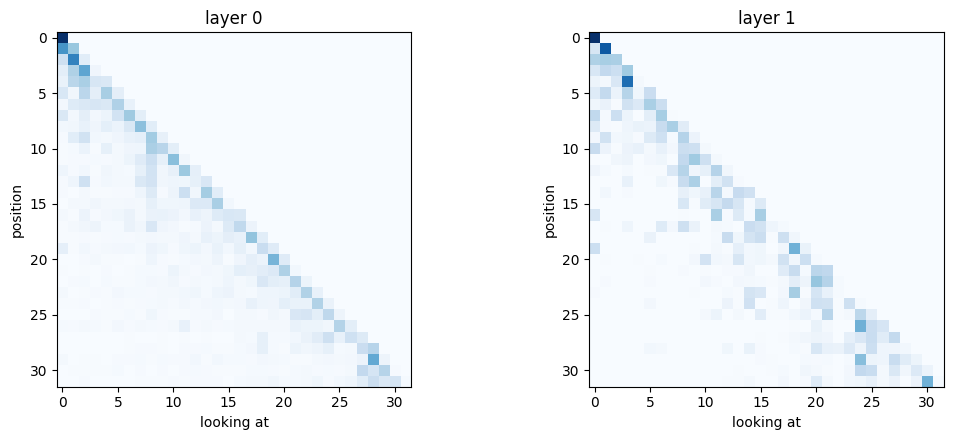

In [11]:
probe = X[:1]
with torch.no_grad():
    _, maps = forward(probe, return_attention=True)

print("attention map per layer :", tuple(maps[0].shape), " (batch, query, key), averaged over heads")

fig, ax = plt.subplots(1, L, figsize=(11,4.5))
letters = [chars[i] for i in probe[0]]
for i in range(L):
    ax[i].imshow(maps[i][0].numpy(), cmap='Blues')
    ax[i].set_title('layer ' + str(i))
    ax[i].set_xlabel('looking at'); ax[i].set_ylabel('position')
plt.tight_layout()
plt.show()

the upper right of both maps is empty, thats the causal mask working, nothing looks into the future.

i expected layer 0 to look at nearby characters and layer 1 to look much further back, thats the usual story. measuring it below to check.

In [12]:
import numpy as np

for i in range(L):
    m = maps[i][0].numpy()
    dist = []
    for q in range(1, BLOCK):
        w = m[q, :q+1]
        positions = np.arange(q+1)
        dist.append(((q - positions) * w).sum() / w.sum())
    print("layer", i, " average distance it looks back :", round(float(np.mean(dist)), 2), "characters")

layer 0  average distance it looks back : 3.88 characters
layer 1  average distance it looks back : 3.63 characters


and the measurement says i was wrong. layer 0 looks back 3.88 characters on average and layer 1 looks back 3.63, so layer 1 is actually looking slightly **closer**, not further.

so no clean division of labour appeared here. with 2 layers, 700 characters and a task that only needs the last few characters to recite a memorised paragraph, there is no reason for a long range head to form. the layers specialising by distance is something reported on real models trained on real corpora, not something guaranteed to show up in a toy one.

## transformer vs the rnn, same data

| | char RNN (Day 49 to 50) | this transformer |
|---|---|---|
| parameters | 24k | 105k |
| training signal per sample | 1 character | 32 characters |
| greedy generation | reproduces the text | reproduces the text |
| sampling at high temperature | breaks into non words | slips to another real sentence |
| can it be parallelised | no, step by step | yes, all positions at once |
| attention readable | no | yes, the maps above |

both memorise, the dataset is 10 lines. the honest comparison is not about quality, its about what the architecture allows.

### what i learned

- a language model head is just predict the next token at every position, and shifting the target by one is the whole trick
- the causal mask is what makes that legal, without it position 5 could read the answer at position 6
- i guessed the two layers would split into short range and long range and the measurement said no, 3.88 vs 3.63 characters. worth measuring instead of repeating what the blog posts say
- the interesting result was the failure mode. the transformer degrades into other real sentences while the rnn degrades into noise, and having the full window instead of one hidden state is the likely reason
- comparing against my own rnn from two folders back was far more useful than comparing against a number from a paper